In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
REPO_ROOT = Path.cwd()

if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

RUN_DIR = REPO_ROOT / "runs" / "run_01_baseline"
EVALUATION_DIR = RUN_DIR / "evaluation"

HISTORY_PATH = RUN_DIR / "history.json"
METRICS_PATH = EVALUATION_DIR / "evaluation_metrics.json"
PER_CLASS_PATH = EVALUATION_DIR / "per_class_metrics.csv"
CONFUSION_MATRIX_PATH = EVALUATION_DIR / "confusion_matrix.png"

print("Repository root:", REPO_ROOT)
print("Run directory:", RUN_DIR)

Repository root: c:\Users\sarun\OneDrive\Desktop\cesppl-internship
Run directory: c:\Users\sarun\OneDrive\Desktop\cesppl-internship\runs\run_01_baseline


In [3]:
with open(HISTORY_PATH, "r", encoding="utf-8") as file:
    history = json.load(file)

history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [4]:
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"

history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
epoch,,,,,
1,0.649012,1.180815,0.891344,0.500557,0.0010
2,0.869565,0.513972,0.913444,0.335757,0.0010
3,0.898024,0.398560,0.933702,0.267200,0.0010
4,0.915810,0.330145,0.942910,0.233217,0.0010
5,0.924111,0.289654,0.937385,0.227677,0.0010
6,0.924901,0.265622,0.942910,0.208341,0.0010
7,0.934387,0.238329,0.948435,0.198432,0.0010
8,0.937945,0.223641,0.946593,0.184268,0.0010
9,0.941107,0.212498,0.952118,0.179766,0.0010


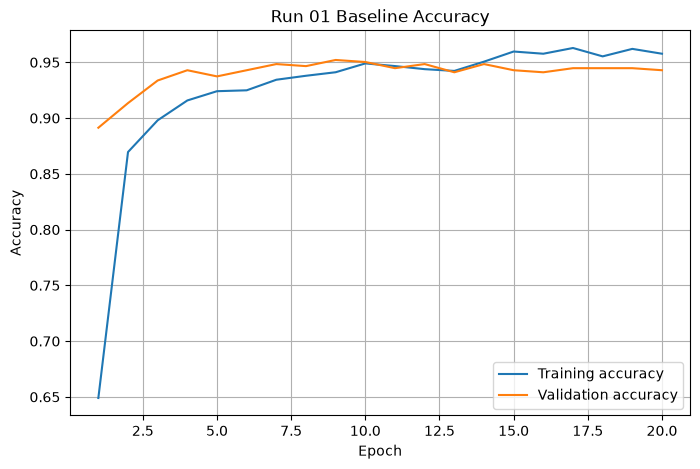

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Run 01 Baseline Accuracy")
plt.legend()
plt.grid(True)
plt.show()

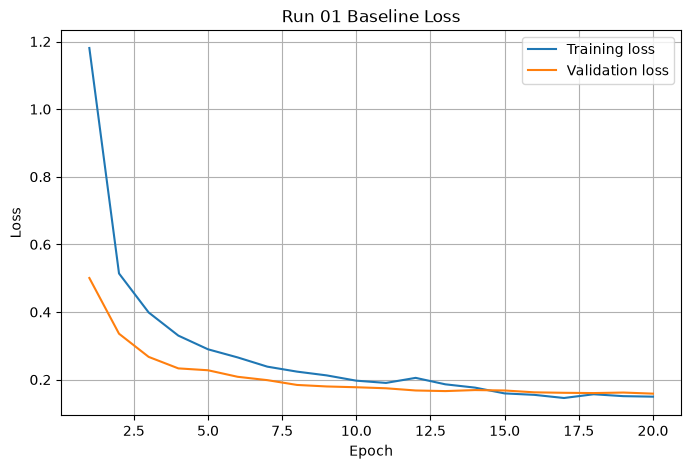

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    label="Training loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Run 01 Baseline Loss")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
with open(METRICS_PATH, "r", encoding="utf-8") as file:
    evaluation_metrics = json.load(file)

print(
    "Validation accuracy:",
    evaluation_metrics["overall_accuracy"]
)

print(
    "Macro F1-score:",
    evaluation_metrics["macro_f1"]
)

Validation accuracy: 0.9429097605893186
Macro F1-score: 0.9150839505852858


In [8]:
per_class_df = pd.read_csv(PER_CLASS_PATH)

per_class_df

,class,precision,recall,f1_score,support
0,BIN LIFTING,0.960000,0.960000,0.960000,25.0
1,BIN WASHING,0.857143,0.979592,0.914286,49.0
2,GATE MEETING,0.959184,0.870370,0.912621,54.0
3,LFC,0.846154,0.550000,0.666667,20.0
4,MANUAL BEACH CLEANING,0.975248,0.989950,0.982544,199.0
5,MECHANICAL SWEEPING,1.000000,1.000000,1.000000,27.0
6,MECHANIZED BEACH CLEANING,0.968750,1.000000,0.984127,31.0
7,PRIMARY COLLECTION,0.933333,0.875000,0.903226,16.0
8,ROAD SWEEPING,0.913580,0.948718,0.930818,78.0
9,SECONDARY VEHICLES,0.906977,0.886364,0.896552,44.0


In [9]:
per_class_df.sort_values(
    by="recall",
    ascending=True
)

,class,precision,recall,f1_score,support
3,LFC,0.846154,0.550000,0.666667,20.0
2,GATE MEETING,0.959184,0.870370,0.912621,54.0
7,PRIMARY COLLECTION,0.933333,0.875000,0.903226,16.0
9,SECONDARY VEHICLES,0.906977,0.886364,0.896552,44.0
8,ROAD SWEEPING,0.913580,0.948718,0.930818,78.0
0,BIN LIFTING,0.960000,0.960000,0.960000,25.0
1,BIN WASHING,0.857143,0.979592,0.914286,49.0
4,MANUAL BEACH CLEANING,0.975248,0.989950,0.982544,199.0
6,MECHANIZED BEACH CLEANING,0.968750,1.000000,0.984127,31.0
5,MECHANICAL SWEEPING,1.000000,1.000000,1.000000,27.0


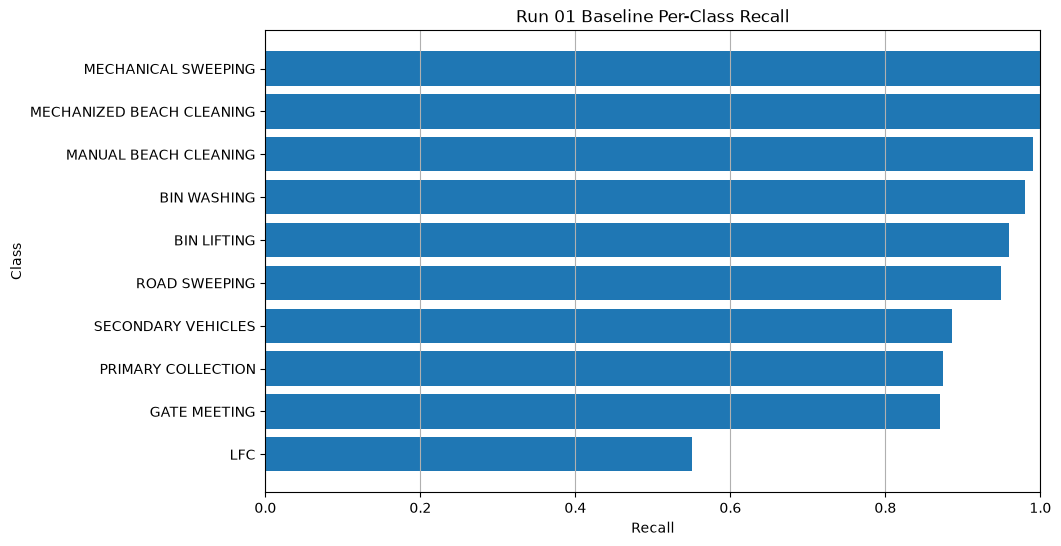

In [10]:
recall_df = per_class_df.sort_values(
    by="recall",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    recall_df["class"],
    recall_df["recall"]
)

plt.xlabel("Recall")
plt.ylabel("Class")
plt.title("Run 01 Baseline Per-Class Recall")
plt.xlim(0, 1)
plt.grid(axis="x")
plt.show()

In [11]:
small_classes = [
    "BIN LIFTING",
    "PRIMARY COLLECTION",
    "LFC",
]

small_class_results = per_class_df[
    per_class_df["class"].isin(small_classes)
][
    [
        "class",
        "precision",
        "recall",
        "f1_score",
        "support",
    ]
]

small_class_results

,class,precision,recall,f1_score,support
0,BIN LIFTING,0.960000,0.960,0.960000,25.0
3,LFC,0.846154,0.550,0.666667,20.0
7,PRIMARY COLLECTION,0.933333,0.875,0.903226,16.0


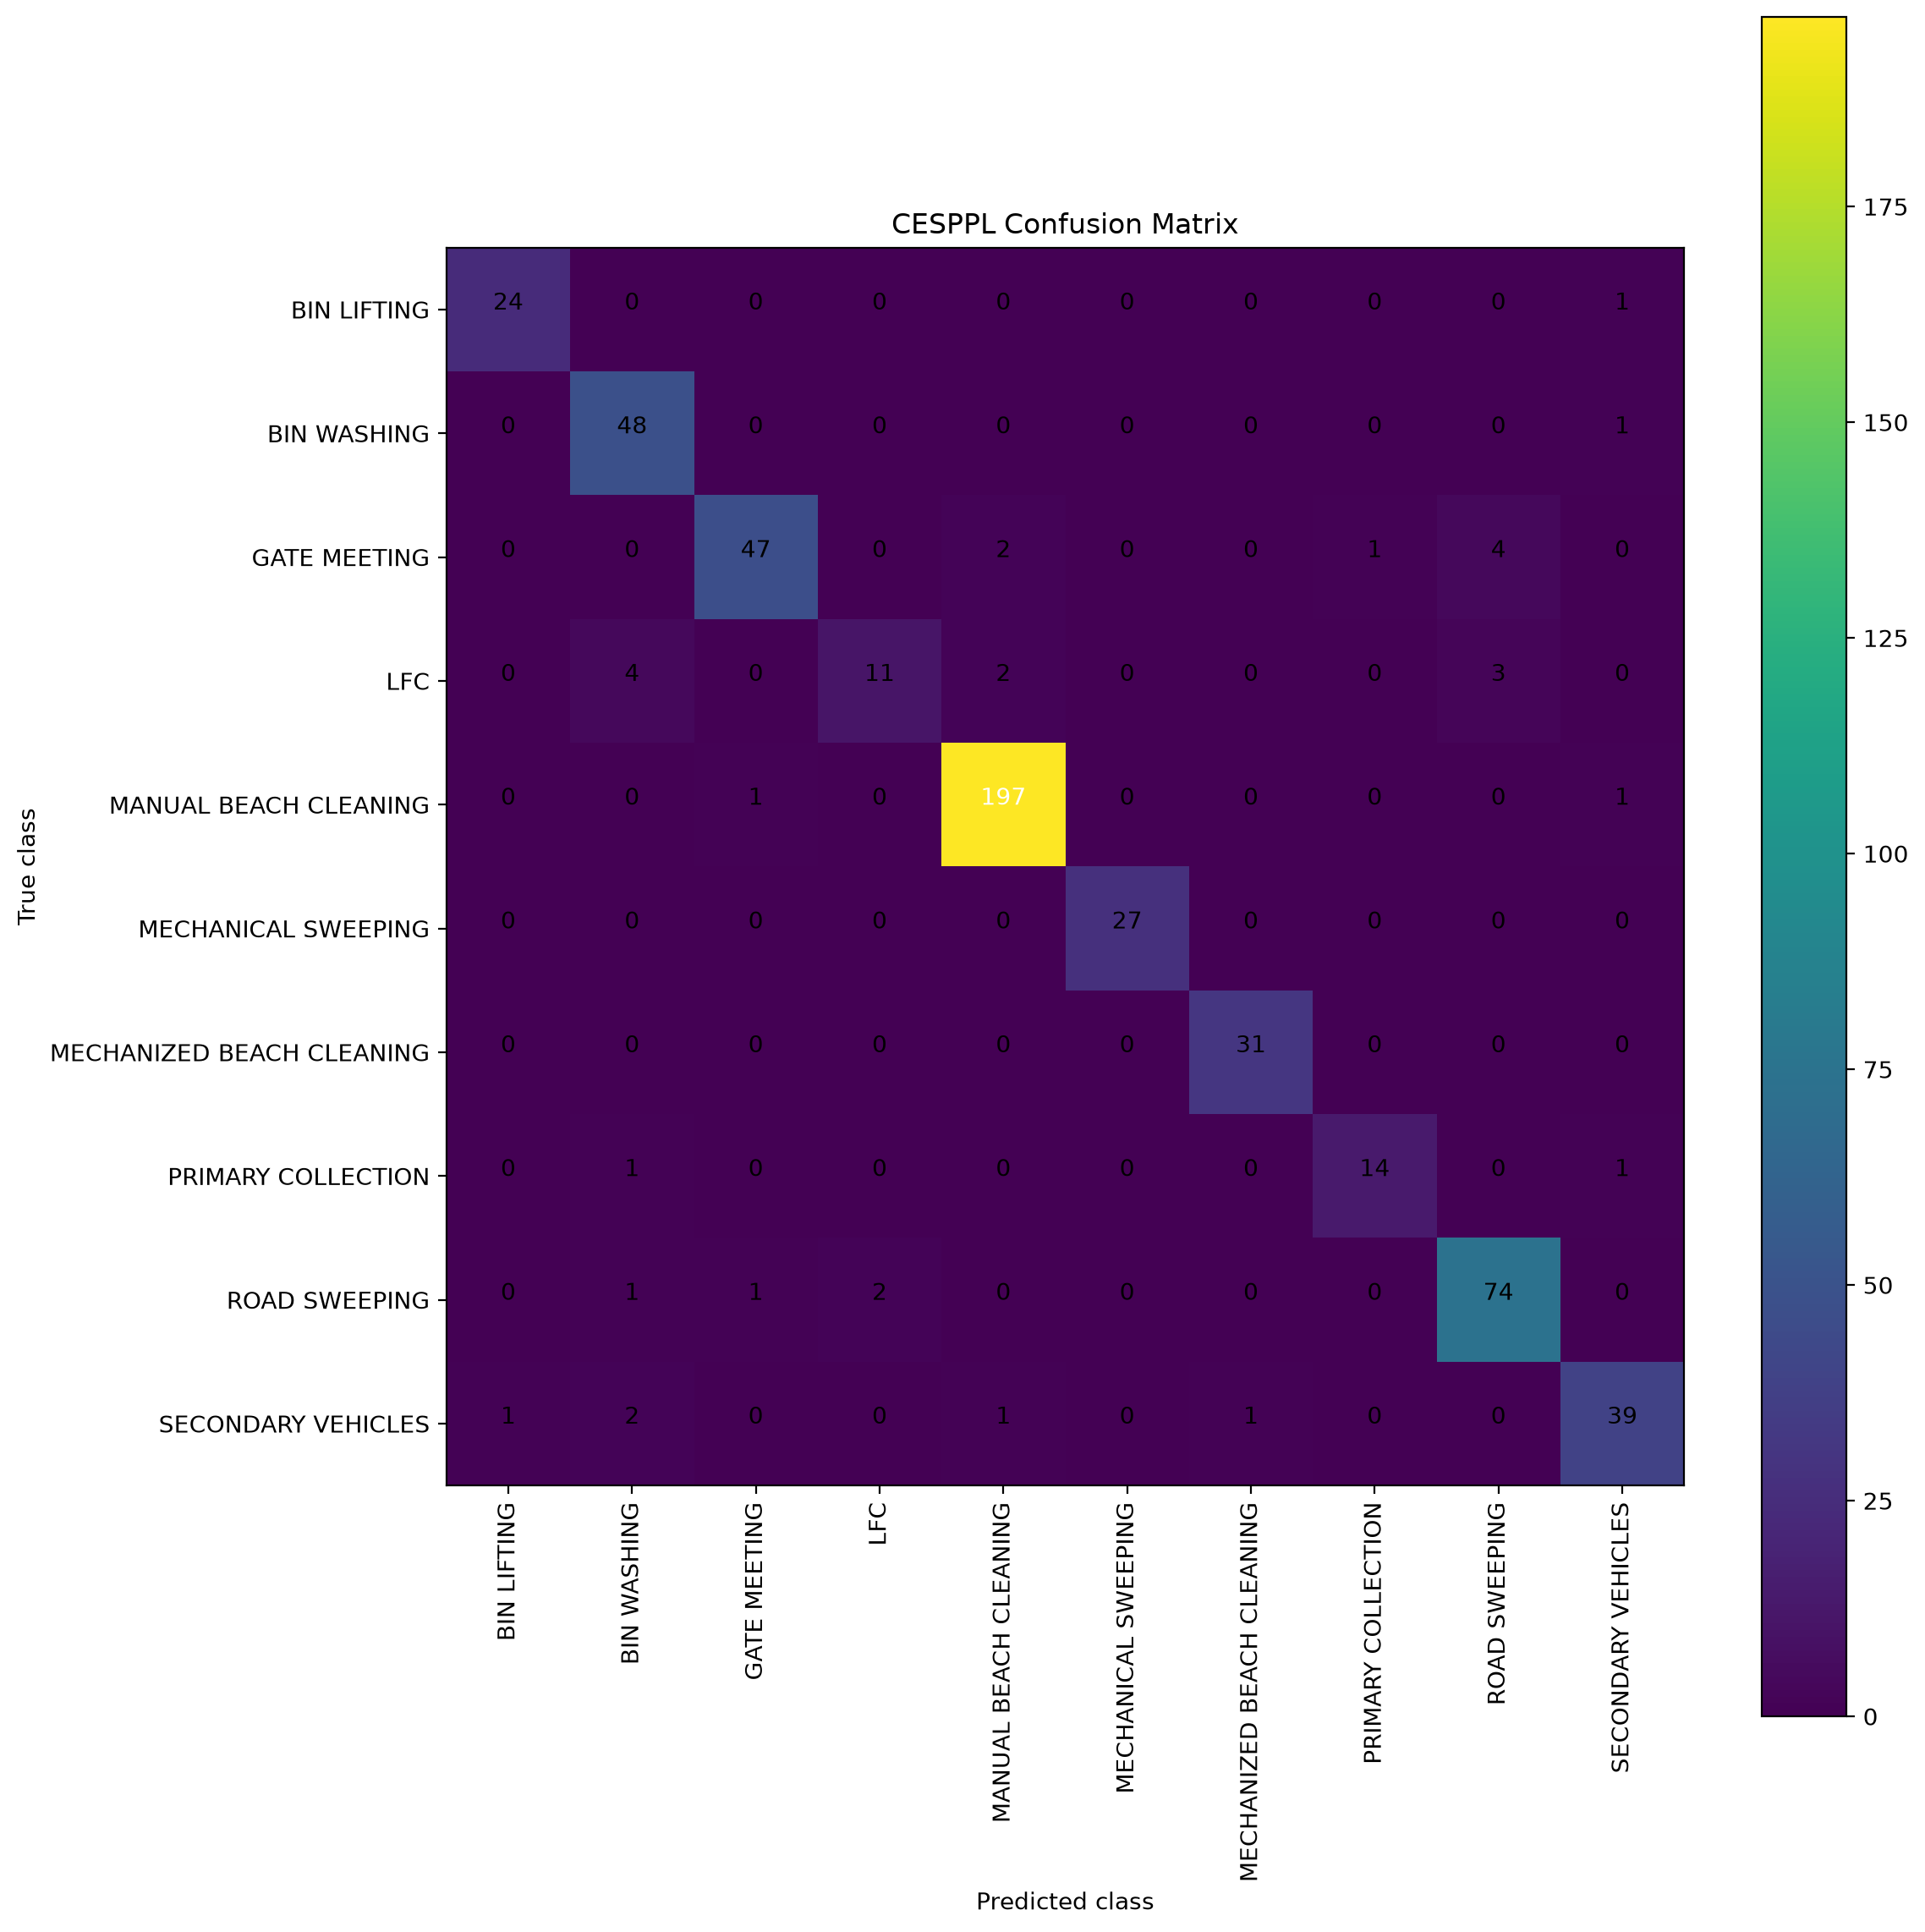

In [12]:
from IPython.display import Image, display

display(
    Image(
        filename=str(CONFUSION_MATRIX_PATH)
    )
)

# Run 01 Baseline Observations

## Overall performance

- Validation accuracy:
- Macro F1-score:
- Best validation epoch:
- Lowest validation loss:

## Small-class performance

- BIN LIFTING recall:
- PRIMARY COLLECTION recall:
- LFC recall:

## Main observations

1. The model learned meaningful features from the CESPPL dataset.
2. Overall accuracy was stronger than or close to the expected baseline range.
3. The minority classes showed lower recall than the larger classes.
4. Class weighting will be tested in a future run to determine whether minority-class recall improves.
5. The confusion matrix revealed which operational classes were most frequently confused.

## Next experiment

Run the same EfficientNetB0 configuration with balanced class weights and compare:

- Overall validation accuracy
- Macro F1-score
- Minority-class recall
- Confusion matrix

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Change this only if the notebook is not inside the notebooks folder.
PROJECT_ROOT = Path("..").resolve()

RUNS = {
    "Run 01 - Baseline EfficientNetB0": PROJECT_ROOT / "runs" / "run_01_baseline",
    "Run 02 - Weighted EfficientNetB0": PROJECT_ROOT / "runs" / "run_02_weighted",
    "Run 03 - Weighted MobileNetV2": PROJECT_ROOT / "runs" / "run_03_mobilenet",
}

for run_name, run_path in RUNS.items():
    print(f"{run_name}: {run_path}")
    print("Exists:", run_path.exists())
    print()
    

Run 01 - Baseline EfficientNetB0: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\runs\run_01_baseline
Exists: True

Run 02 - Weighted EfficientNetB0: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\runs\run_02_weighted
Exists: True

Run 03 - Weighted MobileNetV2: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\runs\run_03_mobilenet
Exists: True



In [3]:
def find_evaluation_file(run_path: Path, filename: str) -> Path:
    possible_paths = [
        run_path / "evaluation" / filename,
        run_path / filename,
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename} inside {run_path} "
        f"or {run_path / 'evaluation'}"
    )


In [6]:
sample_path = find_evaluation_file(
    RUNS["Run 01 - Baseline EfficientNetB0"],
    "evaluation_metrics.json"
)

with open(sample_path, "r", encoding="utf-8") as file:
    sample_metrics = json.load(file)

print(sample_metrics)
print(sample_metrics.keys())

{'checkpoint': 'C:\\Users\\sarun\\OneDrive\\Desktop\\cesppl-internship\\runs\\run_01_baseline\\best.weights.h5', 'split': 'val', 'backbone': 'efficientnetb0', 'overall_accuracy': 0.9429097605893186, 'macro_f1': 0.9150839505852858, 'number_of_samples': 543, 'per_class_metrics': {'BIN LIFTING': {'precision': 0.96, 'recall': 0.96, 'f1_score': 0.96, 'support': 25}, 'BIN WASHING': {'precision': 0.8571428571428571, 'recall': 0.9795918367346939, 'f1_score': 0.9142857142857143, 'support': 49}, 'GATE MEETING': {'precision': 0.9591836734693877, 'recall': 0.8703703703703703, 'f1_score': 0.912621359223301, 'support': 54}, 'LFC': {'precision': 0.8461538461538461, 'recall': 0.55, 'f1_score': 0.6666666666666666, 'support': 20}, 'MANUAL BEACH CLEANING': {'precision': 0.9752475247524752, 'recall': 0.9899497487437185, 'f1_score': 0.9825436408977556, 'support': 199}, 'MECHANICAL SWEEPING': {'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0, 'support': 27}, 'MECHANIZED BEACH CLEANING': {'precision': 0.9687

In [7]:
overall_rows = []

for run_name, run_path in RUNS.items():
    metrics_path = find_evaluation_file(
        run_path,
        "evaluation_metrics.json"
    )

    with open(metrics_path, "r", encoding="utf-8") as file:
        metrics = json.load(file)

    accuracy = (
        metrics.get("accuracy")
        or metrics.get("overall_accuracy")
        or metrics.get("validation_accuracy")
        or metrics.get("val_accuracy")
        or metrics.get("test_accuracy")
    )

    macro_f1 = (
        metrics.get("macro_f1")
        or metrics.get("macro_f1_score")
        or metrics.get("f1_macro")
    )

    overall_rows.append({
        "Run": run_name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
    })

overall_comparison = pd.DataFrame(overall_rows)
overall_comparison

,Run,Accuracy,Macro F1
0,Run 01 - Baseline EfficientNetB0,0.942910,0.915084
1,Run 02 - Weighted EfficientNetB0,0.944751,0.928016
2,Run 03 - Weighted MobileNetV2,0.935543,0.910869


In [8]:
display_comparison = overall_comparison.copy()

for column in ["Accuracy", "Macro F1"]:
    display_comparison[column] = (
        pd.to_numeric(display_comparison[column], errors="coerce") * 100
    ).round(2)

display_comparison

,Run,Accuracy,Macro F1
0,Run 01 - Baseline EfficientNetB0,94.29,91.51
1,Run 02 - Weighted EfficientNetB0,94.48,92.80
2,Run 03 - Weighted MobileNetV2,93.55,91.09


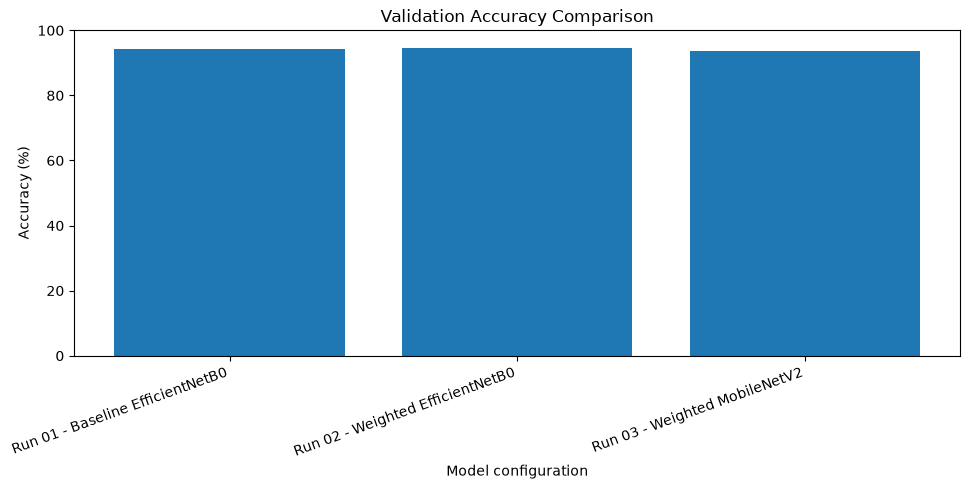

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    display_comparison["Run"],
    display_comparison["Accuracy"]
)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model configuration")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

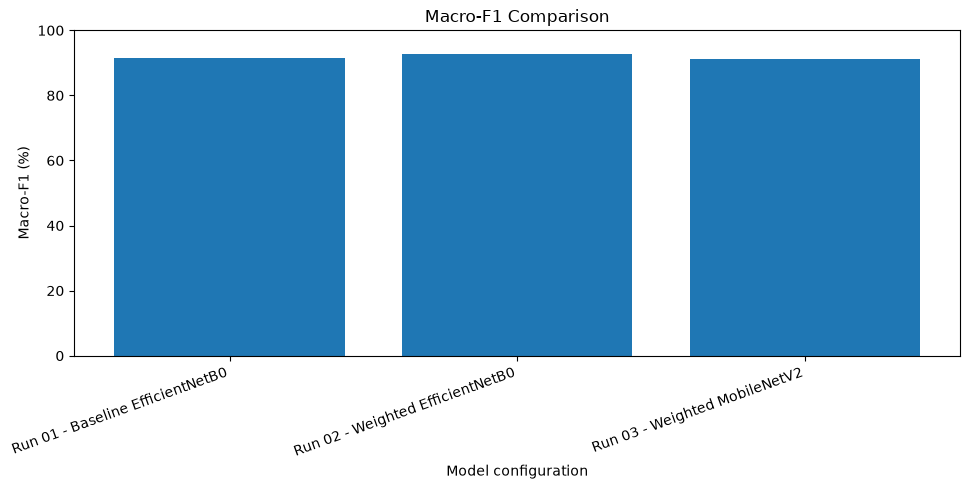

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    display_comparison["Run"],
    display_comparison["Macro F1"]
)

plt.title("Macro-F1 Comparison")
plt.ylabel("Macro-F1 (%)")
plt.xlabel("Model configuration")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [11]:
def load_per_class_metrics(run_path: Path) -> pd.DataFrame:
    metrics_path = find_evaluation_file(
        run_path,
        "per_class_metrics.csv"
    )

    dataframe = pd.read_csv(metrics_path)

    dataframe.columns = [
        column.strip().lower().replace(" ", "_").replace("-", "_")
        for column in dataframe.columns
    ]

    rename_map = {
        "class": "class_name",
        "label": "class_name",
        "category": "class_name",
        "f1": "f1_score",
        "f1score": "f1_score",
    }

    dataframe = dataframe.rename(columns=rename_map)

    required_columns = {"class_name", "recall"}

    missing_columns = required_columns - set(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"Missing columns in {metrics_path}: {missing_columns}. "
            f"Available columns: {list(dataframe.columns)}"
        )

    dataframe["class_name"] = (
        dataframe["class_name"]
        .astype(str)
        .str.strip()
        .str.replace("_", " ", regex=False)
        .str.upper()
    )

    dataframe["recall"] = pd.to_numeric(
        dataframe["recall"],
        errors="coerce"
    )

    return dataframe

In [12]:
recall_tables = []

for run_name, run_path in RUNS.items():
    metrics_df = load_per_class_metrics(run_path)

    run_recall = metrics_df[["class_name", "recall"]].copy()
    run_recall = run_recall.rename(columns={"recall": run_name})

    recall_tables.append(run_recall)

recall_comparison = recall_tables[0]

for table in recall_tables[1:]:
    recall_comparison = recall_comparison.merge(
        table,
        on="class_name",
        how="outer"
    )

recall_comparison

,class_name,Run 01 - Baseline EfficientNetB0,Run 02 - Weighted EfficientNetB0,Run 03 - Weighted MobileNetV2
0,BIN LIFTING,0.960000,1.000000,0.920000
1,BIN WASHING,0.979592,0.979592,1.000000
2,GATE MEETING,0.870370,0.888889,0.907407
3,LFC,0.550000,0.800000,0.700000
4,MANUAL BEACH CLEANING,0.989950,0.964824,0.979899
5,MECHANICAL SWEEPING,1.000000,1.000000,0.962963
6,MECHANIZED BEACH CLEANING,1.000000,1.000000,0.967742
7,PRIMARY COLLECTION,0.875000,0.937500,0.875000
8,ROAD SWEEPING,0.948718,0.923077,0.884615
9,SECONDARY VEHICLES,0.886364,0.886364,0.886364


In [13]:
recall_percent = recall_comparison.copy()

run_columns = [column for column in recall_percent.columns if column != "class_name"]

for column in run_columns:
    recall_percent[column] = (
        recall_percent[column] * 100
    ).round(2)

recall_percent

,class_name,Run 01 - Baseline EfficientNetB0,Run 02 - Weighted EfficientNetB0,Run 03 - Weighted MobileNetV2
0,BIN LIFTING,96.00,100.00,92.00
1,BIN WASHING,97.96,97.96,100.00
2,GATE MEETING,87.04,88.89,90.74
3,LFC,55.00,80.00,70.00
4,MANUAL BEACH CLEANING,98.99,96.48,97.99
5,MECHANICAL SWEEPING,100.00,100.00,96.30
6,MECHANIZED BEACH CLEANING,100.00,100.00,96.77
7,PRIMARY COLLECTION,87.50,93.75,87.50
8,ROAD SWEEPING,94.87,92.31,88.46
9,SECONDARY VEHICLES,88.64,88.64,88.64


In [14]:
rare_classes = [
    "BIN LIFTING",
    "LFC",
    "PRIMARY COLLECTION",
]

rare_class_comparison = recall_percent[
    recall_percent["class_name"].isin(rare_classes)
].copy()

rare_class_comparison

,class_name,Run 01 - Baseline EfficientNetB0,Run 02 - Weighted EfficientNetB0,Run 03 - Weighted MobileNetV2
0,BIN LIFTING,96.0,100.00,92.0
3,LFC,55.0,80.00,70.0
7,PRIMARY COLLECTION,87.5,93.75,87.5


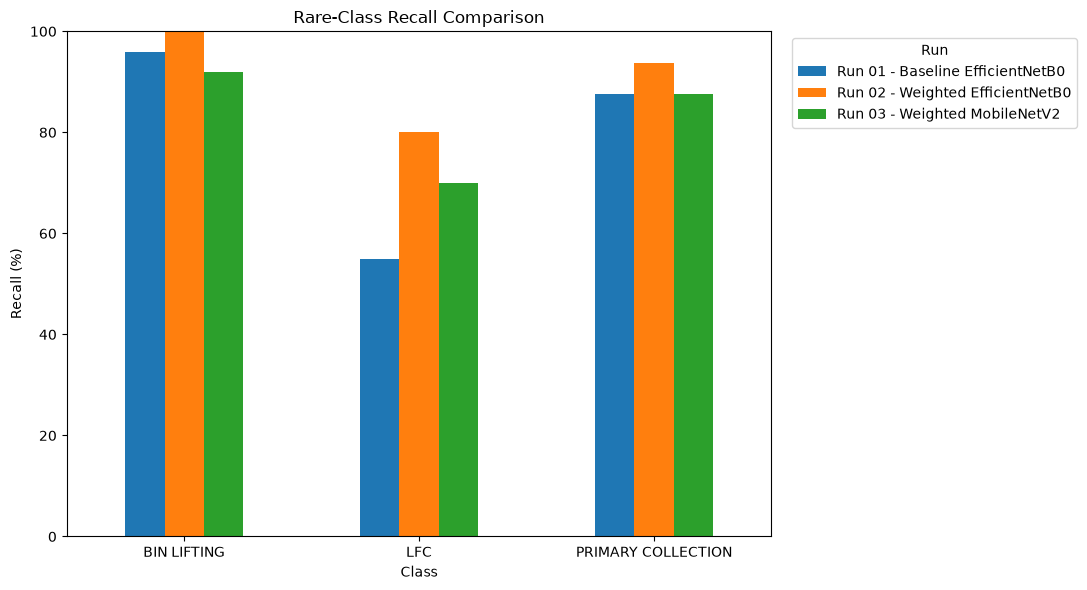

In [15]:
rare_plot_data = rare_class_comparison.set_index("class_name")

rare_plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Rare-Class Recall Comparison")
plt.xlabel("Class")
plt.ylabel("Recall (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

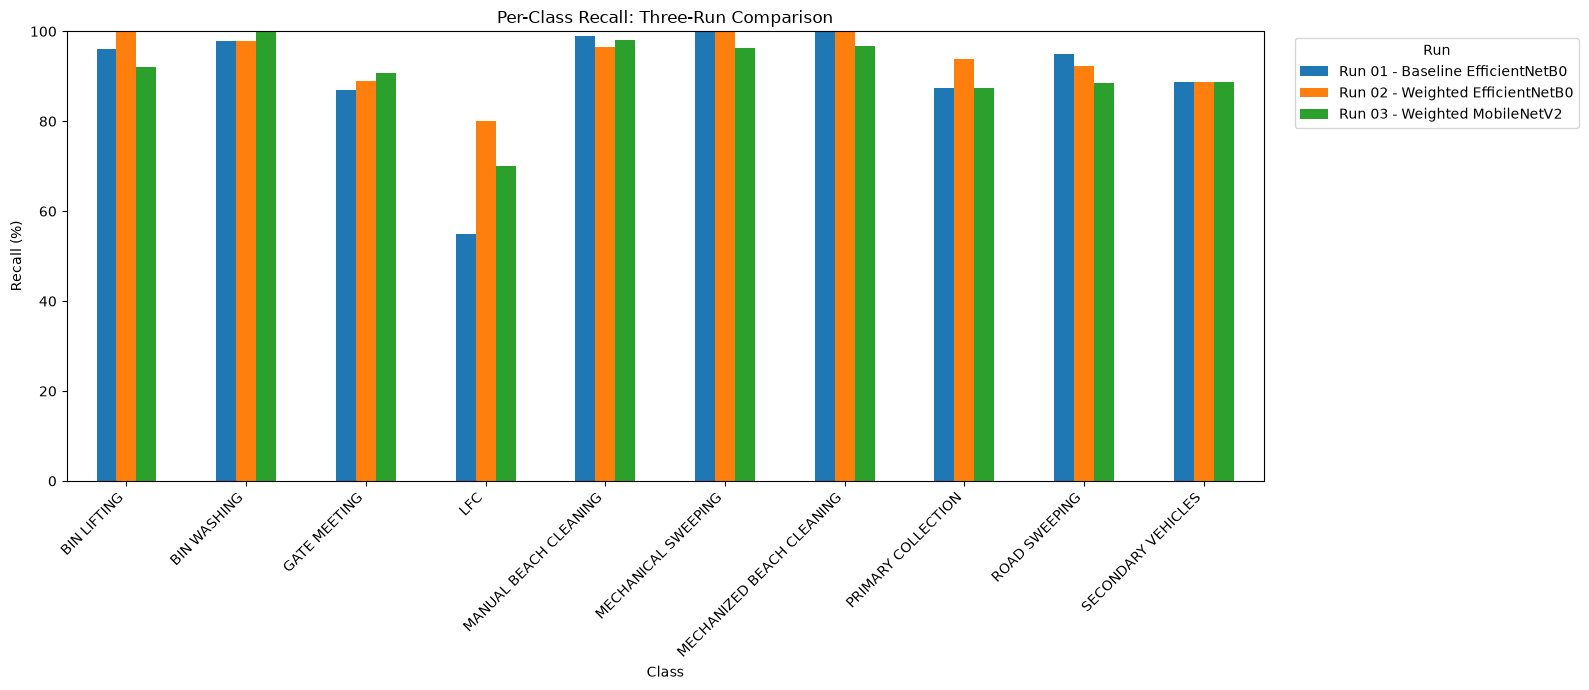

In [16]:
all_recall_plot = recall_percent.set_index("class_name")

all_recall_plot.plot(
    kind="bar",
    figsize=(16, 7)
)

plt.title("Per-Class Recall: Three-Run Comparison")
plt.xlabel("Class")
plt.ylabel("Recall (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

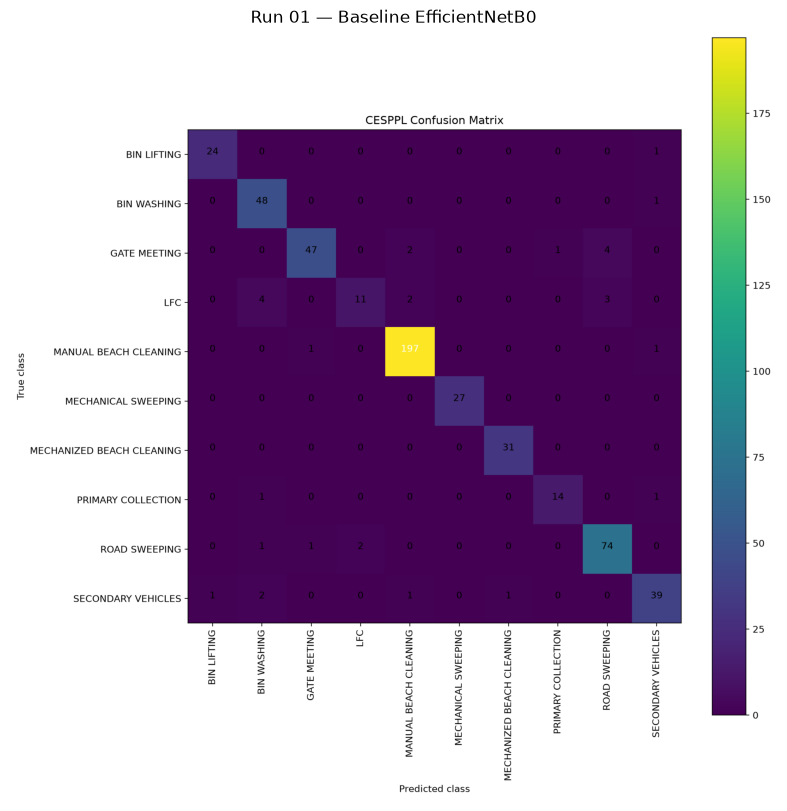

In [17]:
run_01_cm = find_evaluation_file(
    RUNS["Run 01 - Baseline EfficientNetB0"],
    "confusion_matrix.png"
)

image = Image.open(run_01_cm)

plt.figure(figsize=(12, 10))
plt.imshow(image)
plt.axis("off")
plt.title("Run 01 — Baseline EfficientNetB0")
plt.show()

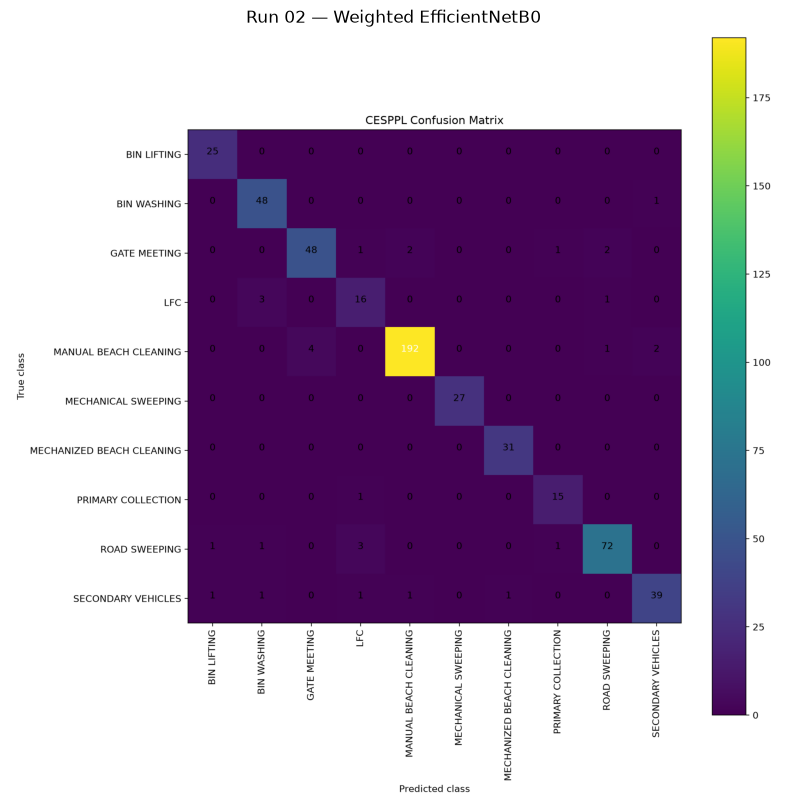

In [18]:
run_02_cm = find_evaluation_file(
    RUNS["Run 02 - Weighted EfficientNetB0"],
    "confusion_matrix.png"
)

image = Image.open(run_02_cm)

plt.figure(figsize=(12, 10))
plt.imshow(image)
plt.axis("off")
plt.title("Run 02 — Weighted EfficientNetB0")
plt.show()

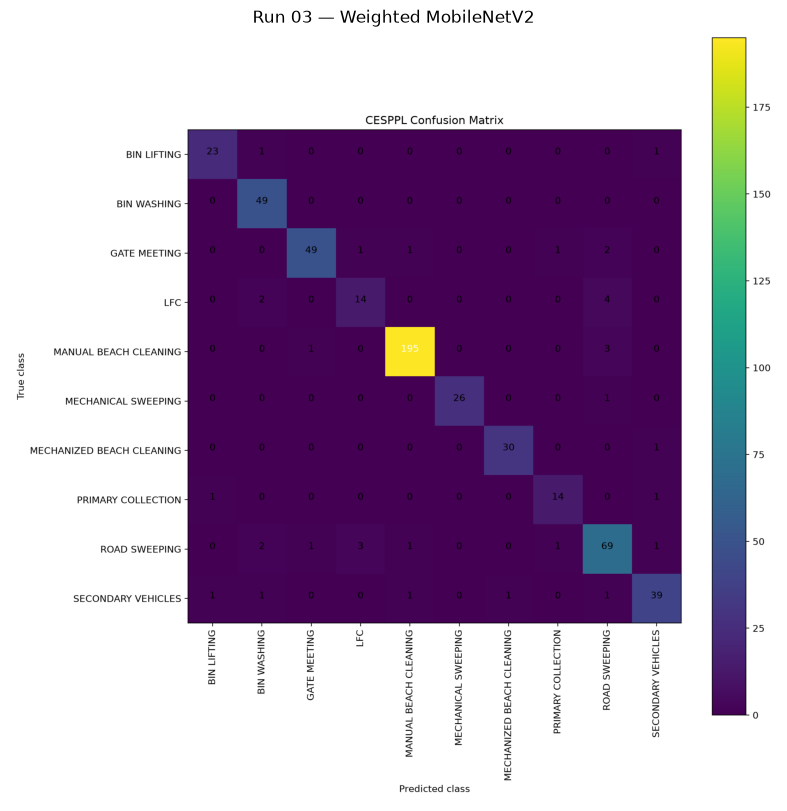

In [19]:
run_03_cm = find_evaluation_file(
    RUNS["Run 03 - Weighted MobileNetV2"],
    "confusion_matrix.png"
)

image = Image.open(run_03_cm)

plt.figure(figsize=(12, 10))
plt.imshow(image)
plt.axis("off")
plt.title("Run 03 — Weighted MobileNetV2")
plt.show()

## Confusion Matrix Analysis

The baseline model showed some confusion between visually similar operational classes.

These errors are likely due to similar vehicle appearance, similar working environments, overlapping background features, limited examples in smaller classes, and similar camera angles.

After applying class weighting, the recall of the rare classes improved while maintaining competitive overall performance.

MobileNetV2 achieved performance close to EfficientNetB0, making it a strong candidate for deployment because of its lightweight architecture and faster CPU inference.

In [21]:
def load_predictions(run_path: Path) -> pd.DataFrame:
    predictions_path = find_evaluation_file(
        run_path,
        "predictions.csv"
    )

    dataframe = pd.read_csv(predictions_path)

    dataframe.columns = [
        column.strip().lower().replace(" ", "_").replace("-", "_")
        for column in dataframe.columns
    ]

    true_candidates = [
        "true_class",
        "true_label",
        "actual_class",
        "actual_label",
        "y_true",
    ]

    predicted_candidates = [
        "predicted_class",
        "predicted_label",
        "prediction",
        "y_pred",
    ]

    true_column = next(
        (column for column in true_candidates if column in dataframe.columns),
        None
    )

    predicted_column = next(
        (column for column in predicted_candidates if column in dataframe.columns),
        None
    )

    if true_column is None or predicted_column is None:
        raise ValueError(
            "Could not identify true and predicted class columns. "
            f"Available columns: {list(dataframe.columns)}"
        )

    dataframe = dataframe.rename(columns={
        true_column: "true_class",
        predicted_column: "predicted_class",
    })

    for column in ["true_class", "predicted_class"]:
        dataframe[column] = (
            dataframe[column]
            .astype(str)
            .str.replace("_", " ", regex=False)
            .str.strip()
            .str.upper()
        )

    return dataframe

In [22]:
run_01_predictions = load_predictions(
    RUNS["Run 01 - Baseline EfficientNetB0"]
)

run_01_errors = run_01_predictions[
    run_01_predictions["true_class"]
    != run_01_predictions["predicted_class"]
]

common_confusions = (
    run_01_errors
    .groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="error_count")
    .sort_values("error_count", ascending=False)
)

common_confusions.head(10)

,true_class,predicted_class,error_count
4,GATE MEETING,ROAD SWEEPING,4
5,LFC,BIN WASHING,4
7,LFC,ROAD SWEEPING,3
16,SECONDARY VEHICLES,BIN WASHING,2
14,ROAD SWEEPING,LFC,2
2,GATE MEETING,MANUAL BEACH CLEANING,2
6,LFC,MANUAL BEACH CLEANING,2
1,BIN WASHING,SECONDARY VEHICLES,1
0,BIN LIFTING,SECONDARY VEHICLES,1
3,GATE MEETING,PRIMARY COLLECTION,1


In [23]:
rare_summary = rare_class_comparison.set_index("class_name").T.reset_index()
rare_summary = rare_summary.rename(columns={"index": "Run"})

final_comparison = display_comparison.merge(
    rare_summary,
    on="Run",
    how="left"
)

final_comparison

,Run,Accuracy,Macro F1,BIN LIFTING,LFC,PRIMARY COLLECTION
0,Run 01 - Baseline EfficientNetB0,94.29,91.51,96.0,55.0,87.50
1,Run 02 - Weighted EfficientNetB0,94.48,92.80,100.0,80.0,93.75
2,Run 03 - Weighted MobileNetV2,93.55,91.09,92.0,70.0,87.50


In [24]:
from datetime import date

experiments_path = PROJECT_ROOT / "experiments.csv"

experiment_rows = []

configuration = {
    "Run 01 - Baseline EfficientNetB0": {
        "run_id": "run_01_baseline",
        "backbone": "efficientnetb0",
        "class_weights": False,
        "epochs": 20,
        "notes": "Baseline EfficientNetB0 without class weighting",
    },
    "Run 02 - Weighted EfficientNetB0": {
        "run_id": "run_02_weighted",
        "backbone": "efficientnetb0",
        "class_weights": True,
        "epochs": 20,
        "notes": "EfficientNetB0 with class weighting",
    },
    "Run 03 - Weighted MobileNetV2": {
        "run_id": "run_03_mobilenet",
        "backbone": "mobilenetv2",
        "class_weights": True,
        "epochs": 20,
        "notes": "Lightweight MobileNetV2 with class weighting",
    },
}

for _, row in final_comparison.iterrows():
    run_name = row["Run"]
    run_config = configuration[run_name]

    experiment_rows.append({
        "run_id": run_config["run_id"],
        "date": date.today().isoformat(),
        "backbone": run_config["backbone"],
        "class_weights": run_config["class_weights"],
        "epochs": run_config["epochs"],
        "accuracy": row["Accuracy"],
        "macro_f1": row["Macro F1"],
        "bin_lifting_recall": row.get("BIN LIFTING"),
        "lfc_recall": row.get("LFC"),
        "primary_collection_recall": row.get("PRIMARY COLLECTION"),
        "notes": run_config["notes"],
    })

new_experiments = pd.DataFrame(experiment_rows)

if experiments_path.exists():
    old_experiments = pd.read_csv(experiments_path)

    combined_experiments = pd.concat(
        [old_experiments, new_experiments],
        ignore_index=True
    )

    combined_experiments = combined_experiments.drop_duplicates(
        subset=["run_id"],
        keep="last"
    )
else:
    combined_experiments = new_experiments

combined_experiments.to_csv(
    experiments_path,
    index=False
)

combined_experiments

,run_id,date,backbone,img_size,epochs,batch_size,learning_rate,dropout,class_weights,val_accuracy,macro_f1,bin_lifting_recall,primary_collection_recall,lfc_recall,checkpoint,notes,accuracy
1,run_01_baseline,2026-07-21,efficientnetb0,NaN,20,NaN,NaN,NaN,False,NaN,91.51,96.0,87.50,55.0,NaN,Baseline EfficientNetB0 without class weighting,94.29
2,run_02_weighted,2026-07-21,efficientnetb0,NaN,20,NaN,NaN,NaN,True,NaN,92.80,100.0,93.75,80.0,NaN,EfficientNetB0 with class weighting,94.48
3,run_03_mobilenet,2026-07-21,mobilenetv2,NaN,20,NaN,NaN,NaN,True,NaN,91.09,92.0,87.50,70.0,NaN,Lightweight MobileNetV2 with class weighting,93.55


## Three-Run Conclusion

The best overall configuration was **[RUN NAME]**, which achieved an accuracy of
**[VALUE]%** and a Macro-F1 score of **[VALUE]%**.

The best rare-class configuration was **[RUN NAME]**. It produced the strongest
combined recall for BIN LIFTING, LFC, and PRIMARY COLLECTION.

Compared with the baseline, class weighting [improved/did not improve] the recall
of the smaller classes. This improvement resulted in [a small/no/a significant]
reduction in the performance of the larger classes.

MobileNetV2 achieved an accuracy of **[VALUE]%**, which was **[VALUE] percentage
points** below/above EfficientNetB0. Because MobileNetV2 is designed for efficient
inference, it remains a strong deployment candidate if its accuracy is close to
EfficientNetB0.

Therefore, the best model for overall classification and the best model for
rare-class protection [are/are not] the same configuration.